# 297 nm single-photon CZ comparison

This notebook is a compact report, not an optimizer scratchpad. It compares the fixed first-pass 297 nm CZ operating point against the existing seven-level time-optimal and `find_phase` adiabatic baselines.

Fixed 297 baseline: `P_297 = 0.56 W` at the atoms, `beam_area = 420 um^2`, `B = 100 G`, `nP = 53P3/2`, `spacing = 3 um`. The primary metric is coherent CZ phase/leakage from logical overlaps, plus the trajectory-integrated loss budget (helpers written inline below).

In [ ]:
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print

import ryd_gate as rg
from ryd_gate import Register, RydbergSystem
from ryd_gate.protocols import CZProtocol, Direct297CZProtocol, Direct297TOProtocol
from ryd_gate.backends.exact import simulate as exact_simulate
from ryd_gate.core.operators import build_sss_state_map
from scipy import integrate, interpolate
from ryd_gate.physics import direct_297_rabis, our_laser_rabis

MHz = 2.0 * np.pi * 1e6
us = 1e-6

SPACING_UM = 3.0
BEAM_AREA_UM2 = 420.0
B_FIELD_G = 100.0
RYD_LEVEL_297 = 53

T_AD = 1.0 * us
D_AMP = 20.0 * MHz
DELTA_CHIRP = 0.0

N_STEPS_AD = 3000   # phase_from_chirp sampling (ODE evolution is adaptive)

RUN_SCANS = True
RUN_297_OPT = False
RUN_DECAY_ON_SANITY = False

if pd is not None:
    pd.options.display.float_format = '{:.6e}'.format


def wrap_to_pi(angle):
    return float((float(angle) + np.pi) % (2.0 * np.pi) - np.pi)



# ---- Inline gate-metric helpers (the formulas live in this notebook) ----

def decay_integrate(t_list, occ_list, decay_rate):
    """Cumulative decay probability P(t) = integral of Gamma*n(tau) dtau.

    Cubic-spline interpolation of the occupation + DOP853 quadrature (the
    convention the cached numbers were produced with; not a trapezoid).
    """
    spline = interpolate.CubicSpline(t_list, occ_list)
    result = integrate.solve_ivp(
        lambda t, _y: np.array([decay_rate * spline(t)]),
        [0, t_list[-1]], np.array([0.0]), t_eval=t_list,
        method="DOP853", rtol=1e-8, atol=1e-12,
    )
    return np.array(result.y)


def _bind_pulse(protocol, x):
    """Protocols are fully specified at construction now (the old TO builders'
    x vector is gone); concrete pulses pass straight through."""
    del x
    return protocol


_OCC_LEVEL = {"e1": "e1", "e2": "e2", "e3": "e3", "ryd": "r", "ryd_garb": "r_garb"}


def population_evolution(system, protocol, x, initial_state):
    """Per-level population time series on the 7-level model (t_list/e1/e2/e3/ryd/ryd_garb)."""
    ini = build_sss_state_map()[initial_state]
    bound = system.with_protocol(_bind_pulse(protocol, x))
    obs = {key: bound.observables.level_sum(lvl) for key, lvl in _OCC_LEVEL.items()}
    res = exact_simulate(bound, ini,
                         t_eval=np.linspace(0.0, bound.t_gate, 1000),
                         observables=obs)
    out = {"t_list": np.asarray(res.times)}
    for key in _OCC_LEVEL:
        out[key] = res.expectation(key).real
    return out


def population_evolution_297(system, protocol, x, initial_state):
    """Rydberg population time series on the 297 nm 4-level model (t_list/ryd/ryd_garb)."""
    ini = system.product_state(initial_state)
    bound = system.with_protocol(_bind_pulse(protocol, x))
    obs = {"ryd": bound.observables.level_sum("r"),
           "ryd_garb": bound.observables.level_sum("r_garb")}
    res = exact_simulate(bound, ini,
                         t_eval=np.linspace(0.0, bound.t_gate, 1000),
                         observables=obs)
    return {
        "t_list": np.asarray(res.times),
        "ryd": res.expectation("ryd").real,
        "ryd_garb": res.expectation("ryd_garb").real,
    }


def error_budget(system, protocol, x, initial_states=("01", "11")):
    """7-level XYZ/AL/LG budget by decay source, averaged over initial states.

    Radiative decay splits back into the qubit (XYZ) vs the other hyperfine
    ground states (LG) by the ARC branching ratios; BBR + final residual
    Rydberg population count as atom loss (AL). Intermediate-manifold decay
    and residuals split by the per-F mid-state branching ratios.
    """
    budget = {src: {"XYZ": 0.0, "AL": 0.0, "LG": 0.0}
              for src in ("rydberg_decay", "intermediate_decay", "polarization_leakage")}
    br = system.level_structure.ryd_branch
    xyz_frac, lg_frac = br["to_0"] + br["to_1"], br["to_L0"] + br["to_L1"]
    for s in initial_states:
        pops = population_evolution(system, protocol, x, s)
        t = pops["t_list"]
        for src, occ in (("rydberg_decay", pops["ryd"]),
                         ("polarization_leakage", pops["ryd_garb"])):
            rd = decay_integrate(t, occ, system.level_structure.ryd_RD_rate)[0, -1]
            bbr = decay_integrate(t, occ, system.level_structure.ryd_BBR_rate)[0, -1]
            budget[src]["XYZ"] += rd * xyz_frac
            budget[src]["LG"] += rd * lg_frac
            budget[src]["AL"] += bbr + occ[-1]
        for F, key in [(1, "e1"), (2, "e2"), (3, "e3")]:
            occ = pops[key]
            mid_total = (decay_integrate(t, occ, system.level_structure.mid_state_decay_rate)[0, -1]
                         + occ[-1])
            mbr = system.level_structure.mid_branch[F]
            budget["intermediate_decay"]["XYZ"] += mid_total * (mbr["to_0"] + mbr["to_1"])
            budget["intermediate_decay"]["LG"] += mid_total * (mbr["to_L0"] + mbr["to_L1"])
    n = len(initial_states)
    return {src: {"total": sum(vals.values()) / n,
                  **{k: v / n for k, v in vals.items()}}
            for src, vals in budget.items()}


def error_budget_297(system, protocol, x, initial_states=("01", "10", "11")):
    """Flat 297 decay/residual budget: Gamma*integral(n dt) + final residuals."""
    gamma = float(system.level_structure.ryd_state_decay_rate)
    accum = dict.fromkeys(("p_ryd_decay", "p_target_ryd_decay", "p_garb_decay",
                           "p_ryd_residual", "p_garb_residual"), 0.0)
    for s in initial_states:
        pops = population_evolution_297(system, protocol, x, s)
        t = pops["t_list"]
        p_target = decay_integrate(t, pops["ryd"], gamma)[0, -1]
        p_garb = decay_integrate(t, pops["ryd_garb"], gamma)[0, -1]
        accum["p_target_ryd_decay"] += p_target
        accum["p_garb_decay"] += p_garb
        accum["p_ryd_decay"] += p_target + p_garb
        accum["p_ryd_residual"] += pops["ryd"][-1]
        accum["p_garb_residual"] += pops["ryd_garb"][-1]
    n = len(initial_states)
    out = {k: float(v / n) for k, v in accum.items()}
    out["p_total"] = out["p_ryd_decay"] + out["p_ryd_residual"] + out["p_garb_residual"]
    return out


BLAS/OpenMP threads pinned to 1


In [8]:
from ryd_gate.physics import our_laser_rabis
from ryd_gate.physics import single_photon_rabi

OPTICS_LOSS = 0.8       # 90% loss of power
Delta = 40.1e3 * MHz  # rad/s, after sys7 is built

beam_area_um2 = 7 * 20 * SPACING_UM
omega_420, omega_1013 = our_laser_rabis(
    p420_w=6*(1 - OPTICS_LOSS),           # 420 nm 功率 (W)
    p1013_w=100*(1 - OPTICS_LOSS),         # 1013 nm 功率 (W)
    beam_area=beam_area_um2,  # 光斑面积 (μm²)
    ryd_level=70,
)
print(f"omega_420/2pi = {omega_420/MHz:.3f} MHz, omega_1013/2pi = {omega_1013/MHz:.3f} MHz")

# Verification
res = single_photon_rabi(
        power_w =100.0*(1 - OPTICS_LOSS), beam_area = beam_area_um2,
        n1=6, l1=1, j1=1.5, mj1=-0.5, n2=70, l2=0, j2=0.5, q=1,
    )/ single_photon_rabi(
        power_w =100.0*(1 - OPTICS_LOSS), beam_area = beam_area_um2,
        n1=6, l1=1, j1=1.5, mj1=-1.5, n2=70, l2=0, j2=0.5, q=1,
    )

print(res**2)

p297_w = 2.8*(1 - OPTICS_LOSS)
# Comparision: single qubit laser: 297
prop_plus = single_photon_rabi(
        power_w = p297_w, beam_area = beam_area_um2,
        n1=5, l1=0, j1=0.5, mj1=-0.5, n2=53, l2=1, j2=1.5, q=-1,
    )/single_photon_rabi(
        power_w = p297_w, beam_area = beam_area_um2,
        n1=5, l1=0, j1=0.5, mj1=0.5, n2=53, l2=1, j2=1.5, q=-1,
    )
prop_minus = single_photon_rabi(
        power_w = p297_w, beam_area = beam_area_um2,
        n1=5, l1=0, j1=0.5, mj1=-0.5, n2=53, l2=1, j2=1.5, q=1,
    )/single_photon_rabi(
        power_w = p297_w, beam_area = beam_area_um2,
        n1=5, l1=0, j1=0.5, mj1=0.5, n2=53, l2=1, j2=1.5, q=1,
    )
prop_pi = single_photon_rabi(
        power_w = p297_w, beam_area = beam_area_um2,
        n1=5, l1=0, j1=0.5, mj1=-0.5, n2=53, l2=1, j2=1.5, q=0,
    )/single_photon_rabi(
        power_w = p297_w, beam_area = beam_area_um2,
        n1=5, l1=0, j1=0.5, mj1=0.5, n2=53, l2=1, j2=1.5, q=0,
    )

prop_297 = single_photon_rabi(
        power_w = p297_w, beam_area = beam_area_um2,
        n1=5, l1=0, j1=0.5, mj1=-0.5, n2=53, l2=1, j2=1.5, q=-1,
    )/single_photon_rabi(
        power_w = p297_w, beam_area = beam_area_um2,
        n1=5, l1=0, j1=0.5, mj1=0.5, n2=53, l2=1, j2=0.5, q=-1,
    )

print(prop_plus**2,prop_minus**2,prop_pi**2,prop_297**2)

# explicit power
omega_297 = single_photon_rabi(
        power_w = p297_w, beam_area = beam_area_um2,
        n1=5, l1=0, j1=0.5, mj1=-0.5, n2=53, l2=1, j2=1.5, q=-1,
    )/2
print(f"omega_297/2pi = {omega_297/MHz:.3f} MHz, omega_eff/2pi = {omega_1013*omega_420/(4*Delta*MHz):.3f} MHz")


omega_420/2pi = 3590.906 MHz, omega_1013/2pi = 692.432 MHz
0.3333333333333334
3.0000000000000018 0.33333333333333315 1.0 2.5295645949127175
omega_297/2pi = 11.349 MHz, omega_eff/2pi = 15.502 MHz


In [ ]:
#   g_J = 1 + (J(J+1) + S(S+1) - L(L+1)) / (2 J(J+1))
#   53P3/2: g_J = 4/3  -> Delta/2pi ≈14.929 MHz
#   70S1/2: g_J ≈ 2    -> Delta/2pi ≈ 22.394 MHz

#   所以它和 n=53 或 n=70 无关，但和 S1/2 vs P3/2 有关。
from ryd_gate.physics import zeeman_shift_rad_s
B = 8.0
singpho_detuning = zeeman_shift_rad_s(
      B, l=1, j=1.5,
      delta_mj=1.0
  )
doubpho_detuning = zeeman_shift_rad_s(
      B, l=0, j=0.5,
      delta_mj=1.0
  )
print(f"single_photon_detuning/2pi = {singpho_detuning/MHz:.3f} MHz")
print(f"double_photon_detuning/2pi = {doubpho_detuning/MHz:.3f} MHz")

single_photon_detuning/2pi = 14.929 MHz
double_photon_detuning/2pi = 22.394 MHz


## Pulse builders

The 297 adiabatic pulse uses a bare phase chirp. The seven-level adiabatic baseline follows `find_phase.ipynb`: smooth 420/1013 envelopes and the Stark-compensated 420 chirp.

In [19]:
from ryd_gate.protocols.gate_cz import phase_from_chirp
OPTICS_LOSS = 0.8

def env(t, ramp=0.15):
    s = float(np.clip(t / T_AD, 0.0, 1.0))
    u = min(s, 1.0 - s)
    if u >= ramp:
        return 1.0
    u = float(np.clip(u / ramp, 0.0, 1.0))
    return 10.0 * u**3 - 15.0 * u**4 + 6.0 * u**5

chirp297 = lambda t: -D_AMP * np.cos(2.0 * np.pi * t / T_AD) + DELTA_CHIRP
phi297 = phase_from_chirp(chirp297, t_gate=T_AD, n_samples=4 * N_STEPS_AD + 1)

P297_W = 3

omega297, omega297_garb = direct_297_rabis(
    P297_W*(1.0 - OPTICS_LOSS), BEAM_AREA_UM2, ryd_level=RYD_LEVEL_297
)

proto297 = Direct297CZProtocol(
    t_gate=T_AD,
    A_297=lambda s: env(float(np.clip(s, 0.0, 1.0)) * T_AD),
    phi_297=lambda s: phi297(float(np.clip(s, 0.0, 1.0)) * T_AD),
    power_at_atoms_w=P297_W*(1.0 - OPTICS_LOSS),
    beam_area_um2=BEAM_AREA_UM2,
)

DELTA_7 = 40.1e3 * MHz
omega420, omega1013 = our_laser_rabis(
    p420_w=6.0 * (1.0 - OPTICS_LOSS),
    p1013_w=100.0 * (1.0 - OPTICS_LOSS),
    beam_area=BEAM_AREA_UM2,
    ryd_level=70,
)

def A420_t(t):
    return env(float(np.clip(t, 0.0, T_AD)), ramp=0.15)

def A1013_t(t):
    return env(float(np.clip(t, 0.0, T_AD)), ramp=0.05)

def chirp7_with_stark(t):
    a = A420_t(t)
    b = A1013_t(t)
    d1_nom = -(4.0 / 3.0) * omega420**2 / (4.0 * DELTA_7)
    dr_nom = -(omega1013**2) / (4.0 * DELTA_7)
    return -D_AMP * np.cos(2.0 * np.pi * t / T_AD) + dr_nom * b * b - d1_nom * a * a + DELTA_CHIRP


phi7 = phase_from_chirp(chirp7_with_stark, t_gate=T_AD, n_samples=4 * N_STEPS_AD + 1)

# CZProtocol takes a normalized duration_ratio = T_AD / T_scale, where
# T_scale = 2*pi / Omega_eff with Omega_eff = omega420*omega1013/(2*|Delta|)
# (what cz_effective_rabi resolves on the bound rb87_7_mp system; DELTA_7
# matches the Delta_Hz used to build sys7 below).
OMEGA_EFF_7 = omega420 * omega1013 / (2.0 * DELTA_7)
proto = CZProtocol(
    duration_ratio=T_AD * OMEGA_EFF_7 / (2.0 * np.pi),
    A_420=lambda s: A420_t(float(np.clip(s, 0.0, 1.0)) * T_AD),
    phi_420=lambda s: phi7(float(np.clip(s, 0.0, 1.0)) * T_AD),
    A_1013=lambda s: A1013_t(float(np.clip(s, 0.0, 1.0)) * T_AD),
    phi_1013=lambda s: 0.0,
    omega_420_max=omega420,
    omega_1013_max=omega1013,
)

print(f"omega_297/2pi = {omega297/MHz:.3f} MHz, omega_garb/2pi = {omega297_garb/MHz:.3f} MHz, omega_420/2pi = {omega420/MHz:.3f} MHz, omega_1013/2pi = {omega1013/MHz:.3f} MHz, omegaeff/2pi = {omega420*omega1013/(4*DELTA_7*MHz):.3f} MHz")



omega_297/2pi = 16.614 MHz, omega_garb/2pi = 9.592 MHz, omega_420/2pi = 3590.906 MHz, omega_1013/2pi = 692.432 MHz, omegaeff/2pi = 15.502 MHz


7L: dim=49, V_nn/2pi=1198.903 MHz
297: dim=16, V_nn/2pi=-131.873 MHz


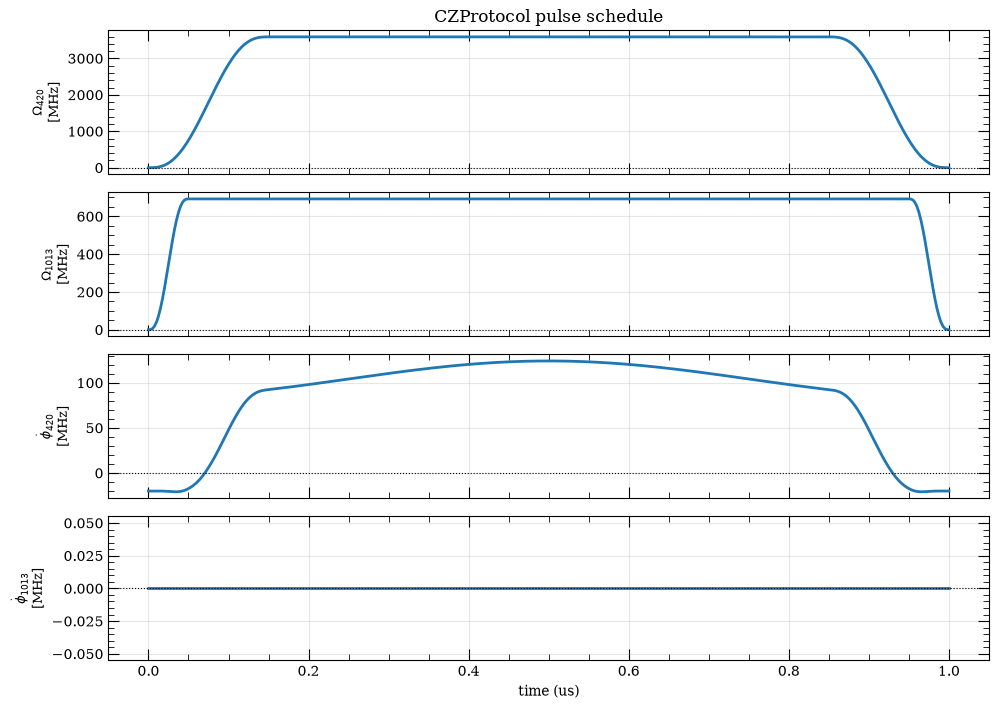

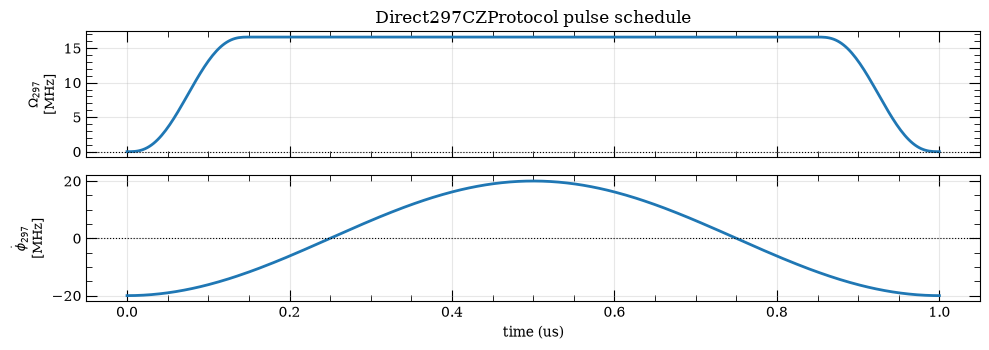

(<Figure size 1000x360 with 2 Axes>,
 [<Axes: title={'center': 'Direct297CZProtocol pulse schedule'}, ylabel='$\\Omega_{297}$\n[MHz]'>,
  <Axes: xlabel='time (us)', ylabel='$\\dot\\phi_{297}$\n[MHz]'>])

In [ ]:
geom = Register.chain(2, spacing_um=SPACING_UM)
level7 = rg.level_structure(
    "rb87_7_mp",
    detuning_sign=1,
    Delta_Hz=Delta / (2 * np.pi),
    magnetic_field_G= B,
)
level297 = rg.level_structure(
    "rb87_297_clock_4",
    magnetic_field_G= B,
    ryd_level=RYD_LEVEL_297,
)

sys7_no_laser = rg.RydbergSystem(level_structure=level7, register=geom)
sys297_no_laser = rg.RydbergSystem(level_structure=level297, register=geom)

sys7 = sys7_no_laser.with_protocol(proto)
sys297 = sys297_no_laser.with_protocol(proto297)

print(
    f"7L: dim={sys7.dim}, V_nn/2pi={sys7.interaction_pairs[0][2] / MHz:.3f} MHz"
)
print(
    f"297: dim={sys297.dim}, V_nn/2pi={sys297.interaction_pairs[0][2] / MHz:.3f} MHz"
)

proto.plot(sys7)
proto297.plot(sys297)


7-level
 s  | return prob | leakage  | phi_full
 00 |  1.000000  | 1.53e-12 | +2.48360
 01 |  0.999721  | 1.60e-04 | +0.66057
 10 |  0.999721  | 1.60e-04 | +0.66057
 11 |  0.992758  | 7.24e-03 | +2.60538
ZZ phase:  -2.515345819426673


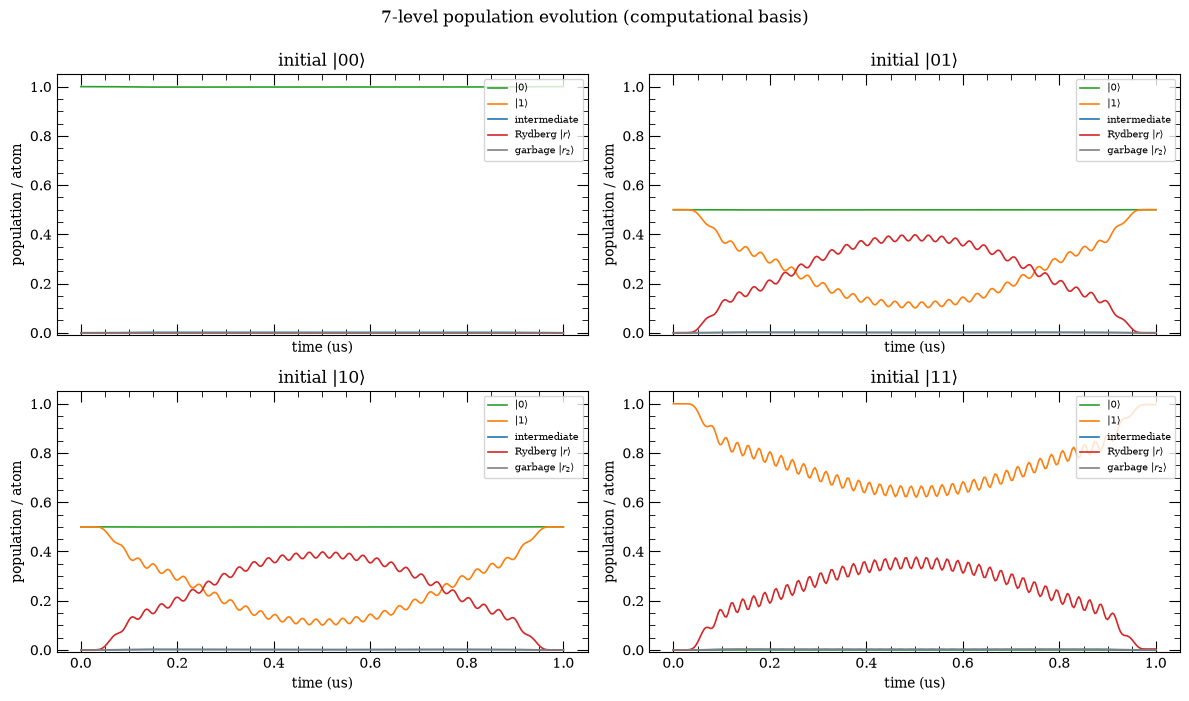

In [ ]:
labels = ["00", "01", "10", "11"]
cfgs = [list(s) for s in labels]
N_EVAL_POP = 301


def simulate_logical_basis(system, t_gate, n_eval=N_EVAL_POP):
    t_eval = np.linspace(0.0, t_gate, n_eval)
    observables = {"sum_n_r": system.observables.level_sum("r"),
                   "sum_n_r_garb": system.observables.level_sum("r_garb")}
    return rg.simulate(system, cfgs, t_eval=t_eval, observables=observables)


def logical_basis_report(system, results, title):
    states = {s: system.product_state(s) for s in labels}
    phases = {}
    print(title)
    print(" s  | return prob | leakage  | phi_full")
    for j, s in enumerate(labels):
        psi_f = results[j].final_state
        ov = np.vdot(states[s], psi_f)
        logical_prob = sum(abs(np.vdot(state, psi_f)) ** 2 for state in states.values())
        leak = 1.0 - logical_prob
        phases[s] = float(np.angle(ov))
        print(f" {s} |  {abs(ov)**2:.6f}  | {leak:.2e} | {phases[s]:+.5f}")
    zz = wrap_to_pi(phases["11"] - phases["01"] - phases["10"] + phases["00"])
    print("ZZ phase: ", zz)
    return phases, zz


def plot_metric_populations(populations, level_specs, *, n_atoms, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
    for ax, s in zip(axes.ravel(), labels):
        pops = populations[s]
        time_us = np.asarray(pops["t_list"], dtype=float) / us
        for name, key, color in level_specs:
            if isinstance(key, tuple):
                y = sum(np.asarray(pops[k], dtype=float) for k in key)
            else:
                y = np.asarray(pops[key], dtype=float)
            ax.plot(time_us, y / n_atoms, lw=1.2, color=color, label=name)
        ax.set_title(f"initial $|{s}\\rangle$")
        ax.set_ylim(-0.01, 1.05)
        ax.set_xlabel("time (us)")
        ax.set_ylabel("population / atom")
        ax.legend(fontsize=7, loc="upper right")
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    plt.show()


# Runtime note: each 7-level exact_ode solve at Delta_e ~ 40 GHz takes several
# minutes at default tolerances; the 4 basis states + 4 population traces below
# add up to tens of minutes.
results7 = simulate_logical_basis(sys7, sys7.t_gate)
phi7_full, zz7 = logical_basis_report(sys7, results7, "7-level")

pop7 = {s: population_evolution(sys7, proto, [], s) for s in labels}
level_specs7 = [
    ("intermediate", ("e1", "e2", "e3"), "tab:blue"),
    (r"Rydberg $|r\rangle$", "ryd", "tab:red"),
    (r"garbage $|r_2\rangle$", "ryd_garb", "gray"),
]
plot_metric_populations(
    pop7,
    level_specs7,
    n_atoms=sys7.N,
    title="7-level excited-state population evolution (inline population_evolution)",
)


297 nm 4-level
 s  | return prob | leakage  | phi_full
 00 |  1.000000  | 0.00e+00 | -0.00000
 01 |  0.999999  | 7.10e-07 | +2.49263
 10 |  0.999999  | 7.10e-07 | +2.49263
 11 |  0.999970  | 3.02e-05 | +2.29621
ZZ phase:  -2.689045374844428


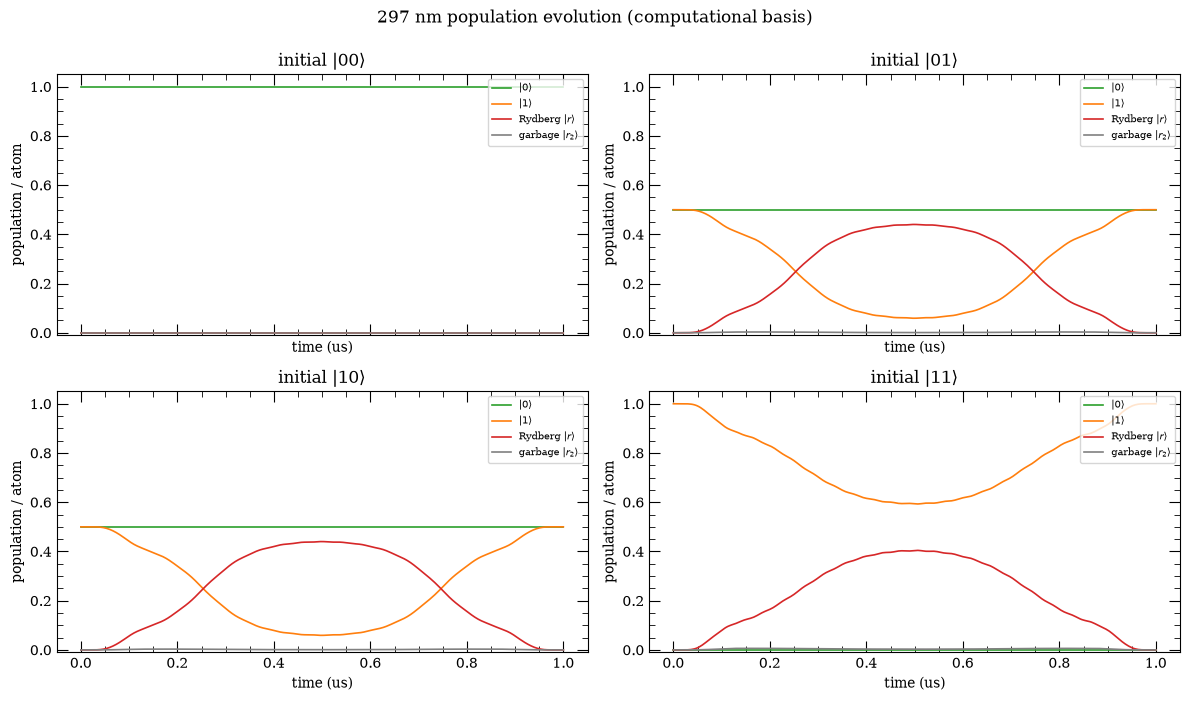

In [22]:
results297 = simulate_logical_basis(sys297, proto297.t_gate)
phi297_full, zz297 = logical_basis_report(sys297, results297, "297 nm 4-level")

pop297 = {s: population_evolution_297(sys297, proto297, [], s) for s in labels}
level_specs297 = [
    (r"Rydberg $|r\rangle$", "ryd", "tab:red"),
    (r"garbage $|r_2\rangle$", "ryd_garb", "gray"),
]
plot_metric_populations(
    pop297,
    level_specs297,
    n_atoms=sys297.N,
    title="297 nm Rydberg population evolution (inline population_evolution_297)",
)


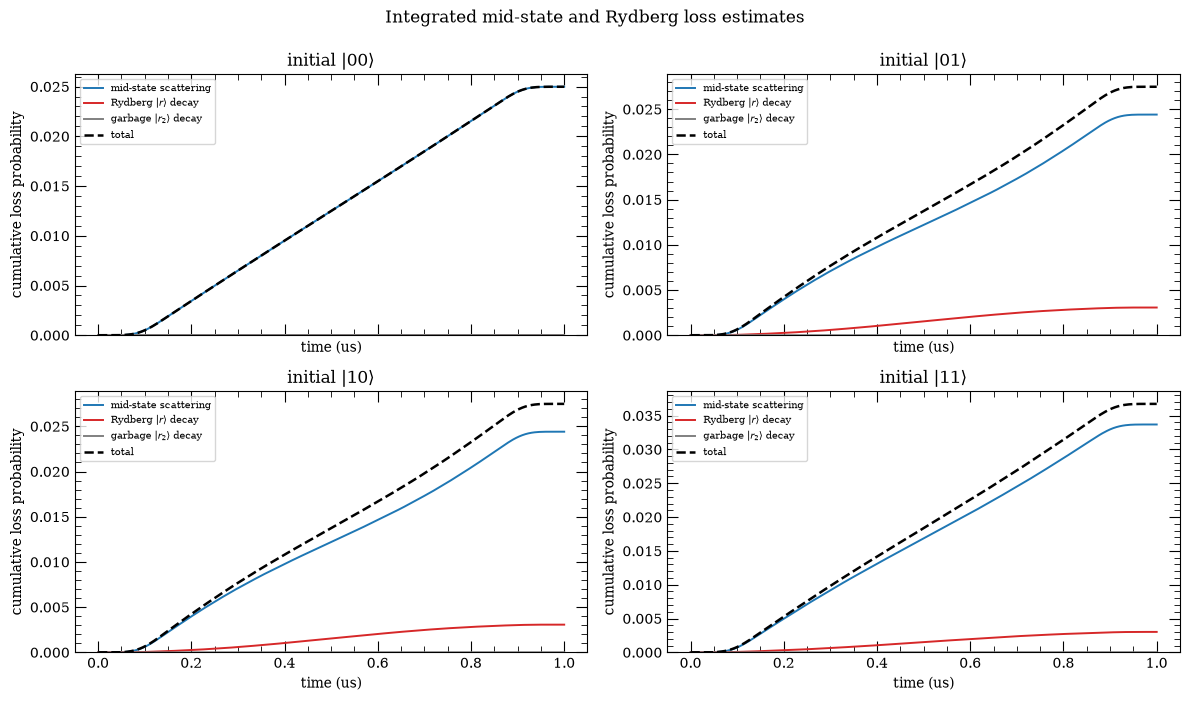

Gamma_e = 9.033424e+06 s^-1
Gamma_r = 6.598482e+03 s^-1
 s  | p_mid      | p_ryd      | p_r_garb   | p_total
 00 | 2.498e-02 | 4.994e-08 | 5.138e-09 | 2.498e-02
 01 | 2.440e-02 | 3.065e-03 | 1.180e-05 | 2.748e-02
 10 | 2.440e-02 | 3.065e-03 | 1.180e-05 | 2.748e-02
 11 | 3.369e-02 | 3.024e-03 | 2.176e-05 | 3.673e-02


In [23]:
# Integrated loss estimates from the trajectory populations (inline helpers).
# These are first-order event probabilities, not a non-Hermitian norm loss.

Gamma_e = float(sys7.level_structure.mid_state_decay_rate)
Gamma_r = float(sys7.level_structure.ryd_state_decay_rate)
Gamma_r_garb = float(sys7.level_structure.ryd_garb_decay_rate)

loss_curves7 = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, s in zip(axes.ravel(), labels):
    pops = pop7[s]
    t = np.asarray(pops["t_list"], dtype=float)
    ne = np.asarray(pops["e1"] + pops["e2"] + pops["e3"], dtype=float)
    nr = np.asarray(pops["ryd"], dtype=float)
    nrg = np.asarray(pops["ryd_garb"], dtype=float)

    p_mid = decay_integrate(t, ne, Gamma_e)[0]
    p_ryd = decay_integrate(t, nr, Gamma_r)[0]
    p_r_garb = decay_integrate(t, nrg, Gamma_r_garb)[0]
    p_total = p_mid + p_ryd + p_r_garb
    loss_curves7[s] = {
        "mid": p_mid,
        "ryd": p_ryd,
        "r_garb": p_r_garb,
        "total": p_total,
        "ne": ne,
        "nr": nr,
        "nrg": nrg,
    }

    ax.plot(t / us, p_mid, lw=1.4, color="tab:blue", label="mid-state scattering")
    ax.plot(t / us, p_ryd, lw=1.4, color="tab:red", label=r"Rydberg $|r\rangle$ decay")
    ax.plot(t / us, p_r_garb, lw=1.4, color="gray", label=r"garbage $|r_2\rangle$ decay")
    ax.plot(t / us, p_total, lw=1.8, color="black", ls="--", label="total")
    ax.set_title(f"initial $|{s}\\rangle$")
    ax.set_xlabel("time (us)")
    ax.set_ylabel("cumulative loss probability")
    ax.set_ylim(bottom=0.0)
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Integrated mid-state and Rydberg loss estimates", y=0.995)
fig.tight_layout()
plt.show()

print(f"Gamma_e = {Gamma_e:.6e} s^-1")
print(f"Gamma_r = {Gamma_r:.6e} s^-1")
print(" s  | p_mid      | p_ryd      | p_r_garb   | p_total")
for s in labels:
    p_mid = loss_curves7[s]["mid"][-1]
    p_ryd = loss_curves7[s]["ryd"][-1]
    p_r_garb = loss_curves7[s]["r_garb"][-1]
    p_total = loss_curves7[s]["total"][-1]
    print(f" {s} | {p_mid:.3e} | {p_ryd:.3e} | {p_r_garb:.3e} | {p_total:.3e}")

budget7 = error_budget(sys7, proto, [], initial_states=["01", "11"])
print("\nerror_budget average over |01>, |11>")
print(" source                 | total     | XYZ       | AL        | LG")
for source, row in budget7.items():
    print(
        f" {source:<22} | {row['total']:.3e} | {row['XYZ']:.3e} | "
        f"{row['AL']:.3e} | {row['LG']:.3e}"
    )


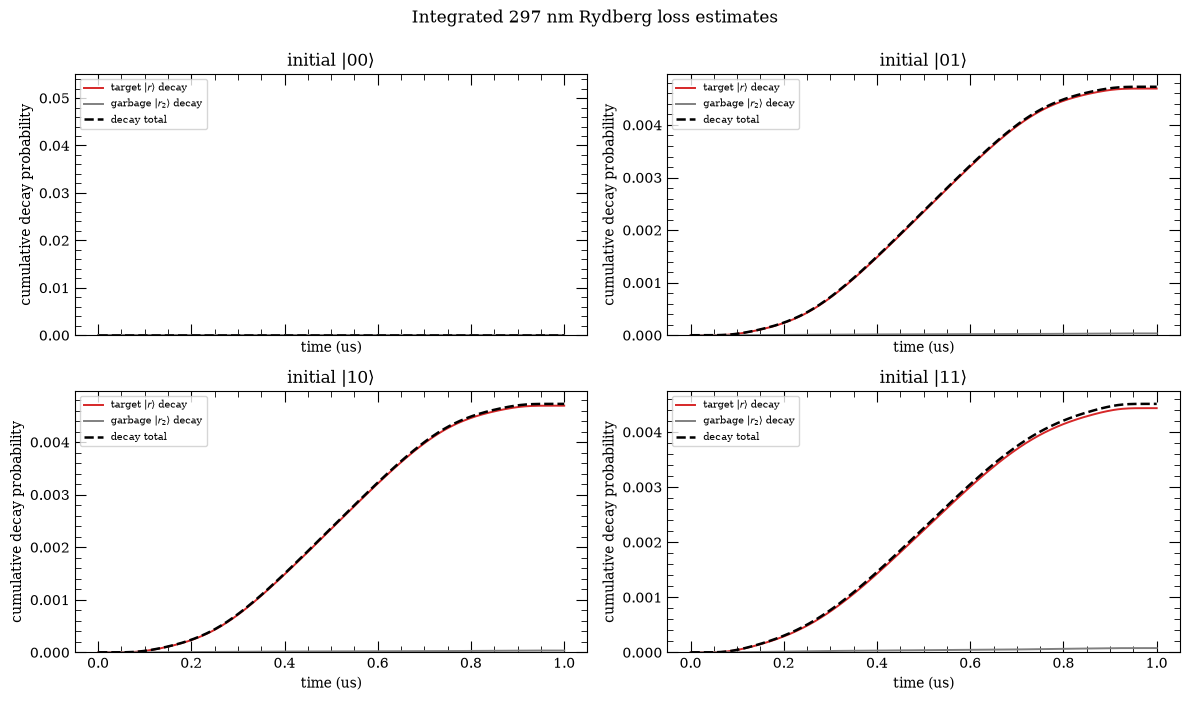

Gamma_297 = 9.970893e+03 s^-1
 s  | p_target   | p_garb     | p_ryd_res  | p_garb_res | p_total
 00 | 0.000e+00 | 0.000e+00 | 0.000e+00 | 0.000e+00 | 0.000e+00
 01 | 4.693e-03 | 3.440e-05 | 7.097e-07 | 5.773e-10 | 4.728e-03
 10 | 4.693e-03 | 3.440e-05 | 7.097e-07 | 5.773e-10 | 4.728e-03
 11 | 4.433e-03 | 7.759e-05 | 3.018e-05 | 4.643e-08 | 4.541e-03


In [24]:
# Integrated loss estimates from the 297 nm four-level trajectories.
# 297 has no intermediate manifold; both |r> and |r_garb> use the nP decay rate.
# The plotted curves are cumulative decay probabilities. The printed p_total
# additionally includes final residual Rydberg population, matching error_budget_297.

Gamma_297 = float(sys297.level_structure.ryd_state_decay_rate)

loss_curves297 = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, s in zip(axes.ravel(), labels):
    pops = pop297[s]
    t = np.asarray(pops["t_list"], dtype=float)
    nr = np.asarray(pops["ryd"], dtype=float)
    nrg = np.asarray(pops["ryd_garb"], dtype=float)

    p_target = decay_integrate(t, nr, Gamma_297)[0]
    p_garb = decay_integrate(t, nrg, Gamma_297)[0]
    p_ryd_decay = p_target + p_garb
    p_ryd_residual = float(nr[-1])
    p_garb_residual = float(nrg[-1])
    p_total = float(p_ryd_decay[-1] + p_ryd_residual + p_garb_residual)
    loss_curves297[s] = {
        "target_ryd_decay": p_target,
        "garb_decay": p_garb,
        "ryd_decay": p_ryd_decay,
        "p_ryd_residual": p_ryd_residual,
        "p_garb_residual": p_garb_residual,
        "p_total": p_total,
        "nr": nr,
        "nrg": nrg,
    }

    ax.plot(t / us, p_target, lw=1.4, color="tab:red", label=r"target $|r\rangle$ decay")
    ax.plot(t / us, p_garb, lw=1.4, color="gray", label=r"garbage $|r_2\rangle$ decay")
    ax.plot(t / us, p_ryd_decay, lw=1.8, color="black", ls="--", label="decay total")
    ax.set_title(f"initial $|{s}\\rangle$")
    ax.set_xlabel("time (us)")
    ax.set_ylabel("cumulative decay probability")
    ax.set_ylim(bottom=0.0)
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Integrated 297 nm Rydberg loss estimates", y=0.995)
fig.tight_layout()
plt.show()

print(f"Gamma_297 = {Gamma_297:.6e} s^-1")
print(" s  | p_target   | p_garb     | p_ryd_res  | p_garb_res | p_total")
for s in labels:
    p_target = loss_curves297[s]["target_ryd_decay"][-1]
    p_garb = loss_curves297[s]["garb_decay"][-1]
    p_ryd_residual = loss_curves297[s]["p_ryd_residual"]
    p_garb_residual = loss_curves297[s]["p_garb_residual"]
    p_total = loss_curves297[s]["p_total"]
    print(
        f" {s} | {p_target:.3e} | {p_garb:.3e} | "
        f"{p_ryd_residual:.3e} | {p_garb_residual:.3e} | {p_total:.3e}"
    )

budget297 = error_budget_297(sys297, proto297, [], initial_states=["01", "10", "11"])
print("\nerror_budget_297 average over |01>, |10>, |11>")
for key, value in budget297.items():
    print(f" {key:<20} = {value:.3e}")
